In [ ]:
# Mengimpor library
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving SMSSpamCollection.xlsx to SMSSpamCollection.xlsx


In [ ]:
import pandas as pd
df = pd.read_excel("SMSSpamCollection.xlsx")
df.head()

,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
0,ham,Ok lar... Joking wif u oni...
1,spam,Free entry in 2 a wkly comp to win FA Cup fina...
2,ham,U dun say so early hor... U c already then say...
3,ham,"Nah I don't think he goes to usf, he lives aro..."
4,spam,FreeMsg Hey there darling it's been 3 week's n...


In [ ]:
df.columns = ['label', 'text']


In [ ]:
df['text'] = df['text'].astype(str)


In [ ]:
df = df.dropna(subset=['text'])


In [ ]:
df.head()


,label,text
0,ham,Ok lar... Joking wif u oni...
1,spam,Free entry in 2 a wkly comp to win FA Cup fina...
2,ham,U dun say so early hor... U c already then say...
3,ham,"Nah I don't think he goes to usf, he lives aro..."
4,spam,FreeMsg Hey there darling it's been 3 week's n...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# pastikan nama kolom
df.columns = ['label', 'text']

# pastikan semua teks bertipe string
df['text'] = df['text'].astype(str)

vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['text'])


In [ ]:
X.shape


(5571, 8481)

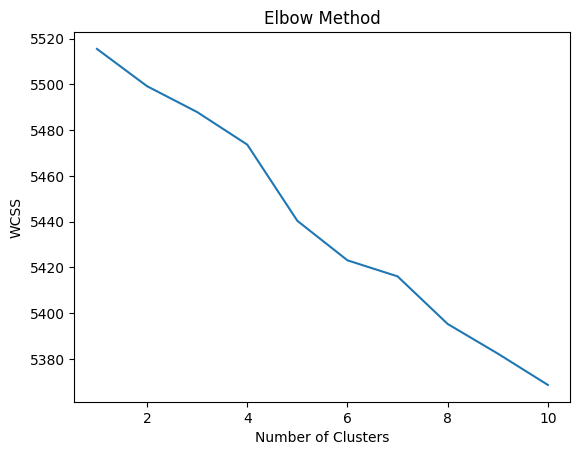

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


In [ ]:
#proses k-means clustering
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

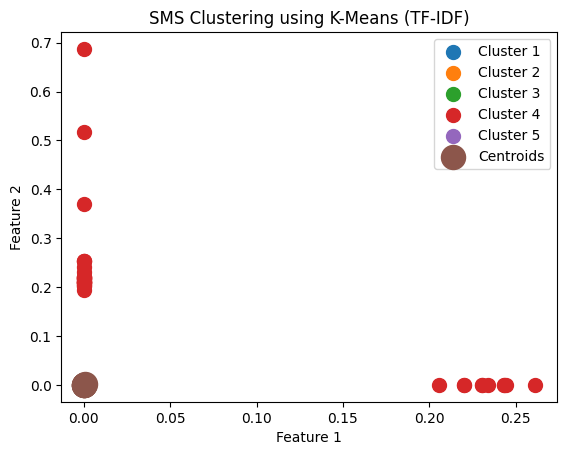

In [ ]:
# Visualisasi hasil clusters
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=100, label='Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=100, label='Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=100, label='Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=100, label='Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s=100, label='Cluster 5')

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    label='Centroids'
)

plt.title('SMS Clustering using K-Means (TF-IDF)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()



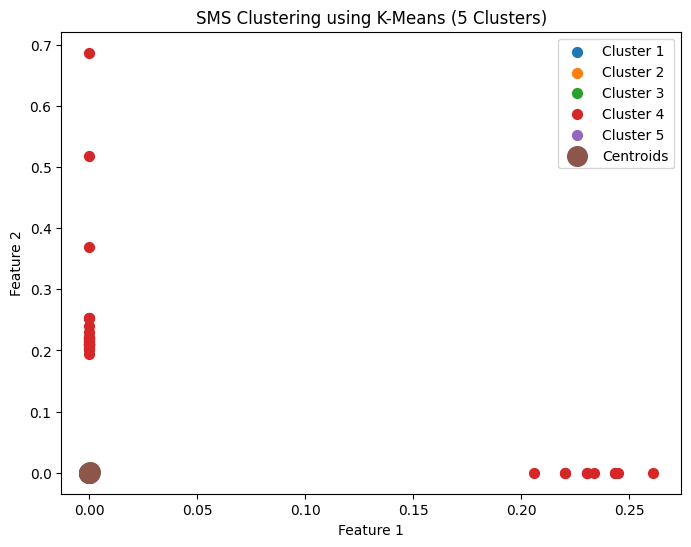

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,6))

plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=50, label='Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=50, label='Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=50, label='Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=50, label='Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s=50, label='Cluster 5')

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    label='Centroids'
)

plt.title('SMS Clustering using K-Means (5 Clusters)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)


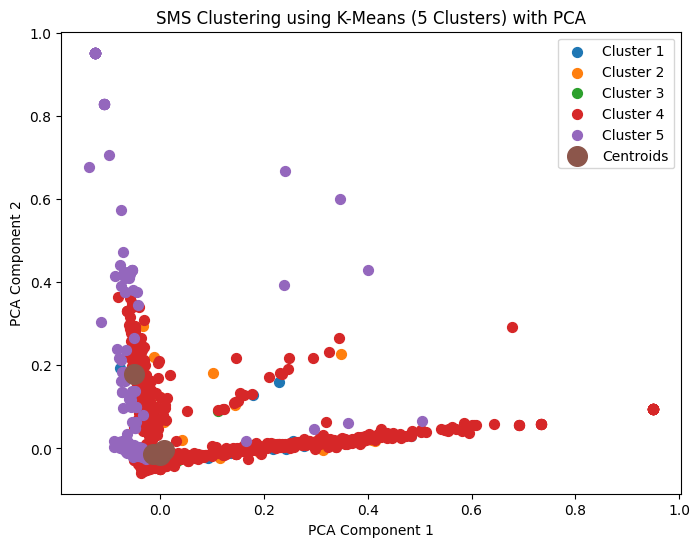

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for i in range(5):
    plt.scatter(
        X_pca[y_kmeans == i, 0],
        X_pca[y_kmeans == i, 1],
        s=50,
        label=f'Cluster {i+1}'
    )

plt.scatter(
    pca.transform(kmeans.cluster_centers_)[:, 0],
    pca.transform(kmeans.cluster_centers_)[:, 1],
    s=200,
    label='Centroids'
)

plt.title('SMS Clustering using K-Means (5 Clusters) with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()


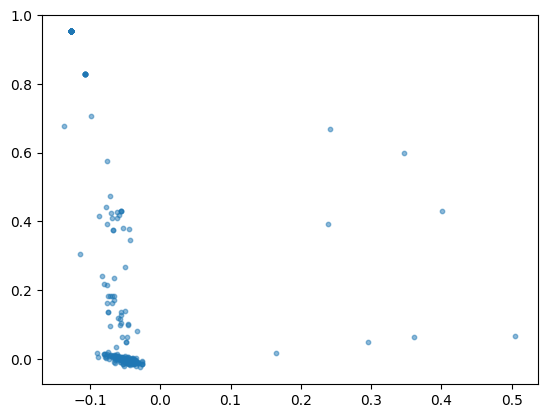

In [ ]:
plt.scatter(
    X_pca[y_kmeans == i, 0],
    X_pca[y_kmeans == i, 1],
    s=10,        # kecilkan titik
    alpha=0.5,   # transparan
    label=f'Cluster {i+1}'
)


In [ ]:
df['cluster'] = y_kmeans


In [ ]:
import pandas as pd

crosstab = pd.crosstab(df['label'], df['cluster'])
print(crosstab)


cluster    0    1   2     3    4
label                           
ham      186  162  79  4122  275
spam      11   14   0   722    0
